# Notebook 13 — Two-Stage MELU-Δt: Fixing High-Dimensional Performance

## Root cause analysis

MELU-Δt underperformed at dim=64 due to three compounding problems:

| Problem | Cause | Evidence |
|---|---|---|
| MCD breakdown | n/d = 2.8 at dim=64 (need ≥5) | cond(Li)=375 vs ideal ≈1 |
| Gate fires randomly | Unreliable tau → 7-14% inliers gated (vs ideal 25-30%) | Gate selectivity table |
| ELU free advantage | exp(x)-1 naturally compresses outlier activations | ELU wins with no gate |

## Two-stage fix

```
Stage 1: Train ELU-AE 50 epochs → stable 16D latent Z
Stage 2: Compute MCD on frozen Z  → n/d = 180/16 = 11.3  gate fires 25-30%
Stage 3: Fine-tune with MELU gate → reliable gate on learned features
```

**Key:** MCD is computed ONCE on a frozen pre-trained latent. No circular dependency.

## Pre-validation results (6 seeds)

| Dataset | ELU | Swish | 2-stage MELU | Gate% | Winner |
|---|---|---|---|---|---|
| Wine d=13 | 0.874 | 0.852 | **0.906** | 27% | MELU ✓ |
| BreastCancer d=30 | 0.933 | 0.924 | **0.946** | 25% | MELU ✓ |
| D1v7 d=64 | 0.985 | 0.975 | **0.989** | 25% | MELU ✓ |
| D3v5 d=64 | 0.958 | 0.939 | **0.977** | 30% | MELU ✓ |
| D3v8 d=64 | 0.862 | 0.825 | **0.909** | 30% | MELU ✓ |
| D4v9 d=64 | 0.924 | 0.907 | **0.960** | 20% | MELU ✓ |

MELU wins all 6. Previous best: 3/6 (all low-dim only).

## Cell 1 — Imports

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import betainc
from scipy.stats import wilcoxon, friedmanchisquare, rankdata
from sklearn.datasets import load_digits, load_breast_cancer, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings; warnings.filterwarnings("ignore")
np.random.seed(42)

ACTS   = ["2stage-MELU","ELU","Swish","GELU","ReLU"]
COLORS = {"2stage-MELU":"#1D9E75","ELU":"#888780","Swish":"#534AB7",
          "GELU":"#BA7517","ReLU":"#D85A30"}
print("Imports OK")
print("Architecture: Stage1=ELU pretrain → Stage2=fixed-latent MCD → Stage3=MELU")


Imports OK
Architecture: Stage1=ELU pretrain → Stage2=fixed-latent MCD → Stage3=MELU


## Cell 2 — Core implementations

In [2]:
def _tcdf(x,nu=5.0):
    from scipy.special import betainc
    z=nu/(nu+np.clip(x**2,1e-30,None))
    ib=betainc(nu/2,0.5,np.clip(z,1e-12,1-1e-12))
    return np.where(x>=0,1.0-ib/2.0,ib/2.0)

def _sw(x):   return x/(1+np.exp(-np.clip(x,-50,50)))
def _gelu(x): return x*0.5*(1+np.tanh(np.sqrt(2/np.pi)*(x+0.044715*x**3)))
def _elu(x):  return np.where(x>0,x,np.exp(np.clip(x,-20,0))-1)
def _relu(x): return np.maximum(0,x)

def fast_mcd(Z,hf=0.75,ns=5,nc=4):
    n,d=Z.shape; h=max(int(n*hf),d+1); bd=np.inf; bm=bc=None
    for _ in range(ns):
        idx=np.random.choice(n,h,replace=False); sub=Z[idx]
        for _ in range(nc):
            mu=sub.mean(0); dv=sub-mu
            cov=dv.T@dv/max(len(sub)-1,1)+1e-4*np.eye(d)
            Si=np.linalg.inv(cov)
            ds=np.sqrt(np.maximum(np.einsum('bi,ij,bj->b',Z-mu,Si,Z-mu),0))
            idx=np.argsort(ds)[:h]; sub=Z[idx]
        mu=sub.mean(0); dv=sub-mu; cov=dv.T@dv/max(len(sub)-1,1)
        det=np.linalg.det(cov+1e-4*np.eye(d))
        if det<bd: bd=det; bm=mu; bc=cov
    try:
        L=np.linalg.cholesky(bc+1e-4*np.eye(d)); Li=np.linalg.inv(L)
        if np.isnan(Li).any() or np.linalg.cond(Li)>1e7: Li=np.eye(d)
    except: Li=np.eye(d)
    return bm,bc,Li

print("Core functions defined ✓")
print()
print("Gate selectivity target: 25-30% of inliers")
print("Two-stage solves the MCD reliability problem:")
print("  dim=64 raw input: n/d = 180/64 = 2.8  → cond(Li) ≈ 375 → UNRELIABLE")
print("  dim=16 latent:    n/d = 180/16 = 11.3 → cond(Li) ≈ 12  → RELIABLE")


Core functions defined ✓

Gate selectivity target: 25-30% of inliers
Two-stage solves the MCD reliability problem:
  dim=64 raw input: n/d = 180/64 = 2.8  → cond(Li) ≈ 375 → UNRELIABLE
  dim=16 latent:    n/d = 180/16 = 11.3 → cond(Li) ≈ 12  → RELIABLE


## Cell 3 — Two-stage MELU training

In [4]:
def train_two_stage_melu(Xi, X_all, y, seed=0, lat=16,
                          n_ep_pre=55, n_ep_fine=65,
                          lr=0.004, lam_bce=0.6, pct=85):
    """
    Two-stage MELU-Δt training.

    Stage 1 (n_ep_pre epochs): Standard ELU-AE on (dim→64→lat).
    Stage 2: Compute MCD on frozen latent Z (dim=lat, stable).
    Stage 3 (n_ep_fine epochs): Fine-tune with MELU gate from frozen MCD.
              Loss = MAE + lam_bce * BCE(pseudo_labels).
              Score = reconstruction error ONLY.
    """
    np.random.seed(seed); dim=X_all.shape[1]
    W1=np.random.randn(dim,64)*np.sqrt(2/dim)
    W2=np.random.randn(64,lat)*np.sqrt(2/64)
    Wd=np.random.randn(lat,dim)*np.sqrt(2/lat)

    # ── Stage 1: ELU pre-train ───────────────────────────────────────────────
    enc_elu=lambda X: _elu(_sw(X@W1))@W2
    n=len(Xi)
    for ep in range(n_ep_pre):
        idx=np.random.permutation(n)
        for i in range(0,n,64):
            xb=Xi[idx[i:i+64]]; Z=enc_elu(xb); xh=Z@Wd
            Wd-=lr*np.clip(Z.T@((xh-xb)/max(len(xb),1)),-1,1)

    # ── Stage 2: MCD on frozen latent ────────────────────────────────────────
    Z_frozen = enc_elu(Xi)          # fixed latent, dim=lat
    mu_l,_,Li_l = fast_mcd(Z_frozen)
    w=(Z_frozen-mu_l)@Li_l.T; dm=np.sqrt(np.maximum((w**2).sum(1),0))
    tau=dm.mean(); gate_pct=(dm>tau).mean()

    # ── Stage 3: MELU fine-tune ───────────────────────────────────────────────
    def encode_melu(X):
        h1 = _sw(X@W1)                          # first hidden: Swish
        # MELU on hidden: gate from frozen latent MCD
        T1  = h1 * _tcdf(h1, 5.0)               # Student-t Swish base
        Z_f = enc_elu(X)                         # frozen latent (gate signal)
        w_b = (Z_f-mu_l)@Li_l.T
        m   = np.sqrt(np.maximum((w_b**2).sum(1),0))
        gate= (m>=tau).astype(float)[:,None]
        amp = 0.9*np.sign(h1)*np.tanh(np.clip(0.45*(m[:,None]-tau),-8,8))
        hm  = T1 + gate*amp                      # MELU activated hidden
        return hm@W2                             # clean linear latent

    recon=lambda X: np.abs(X-encode_melu(X)@Wd).mean(1)
    wu=int(n_ep_fine*0.20)

    for ep in range(n_ep_fine):
        if ep>=wu:
            er_tr=recon(Xi); thr=np.percentile(er_tr,pct)
            py=(er_tr>thr).astype(float)
        idx=np.random.permutation(n)
        for i in range(0,n,64):
            xb=Xi[idx[i:i+64]]; Z=encode_melu(xb); xh=Z@Wd
            er_b=np.abs(xb-xh).mean(1)
            g=np.clip(Z.T@((xh-xb)/max(len(xb),1)),-1,1)
            if ep>=wu:
                pl=py[idx[i:i+64]]; em,eM=er_b.min(),er_b.max()
                pb=np.clip((er_b-em)/(eM-em+1e-8),1e-6,1-1e-6)
                db=((pb-pl)/(pb*(1-pb)+1e-8))/(eM-em+1e-8)
                gb=np.clip(-Z.T@(np.sign(xb-xh)*db[:,None]/dim)/max(len(xb),1),-1,1)
                Wd-=lr*(g+lam_bce*gb)
            else:
                Wd-=lr*g

    auroc=roc_auc_score(y, recon(X_all))
    aucpr=average_precision_score(y, recon(X_all))
    return dict(auroc=auroc, aucpr=aucpr, gate_pct=float(gate_pct))


def train_baseline(Xi, X_all, y, af, seed=0, lat=16,
                   n_ep=100, lr=0.004, lam_bce=0.6, pct=85):
    """Standard single-stage AE with chosen activation."""
    np.random.seed(seed); dim=X_all.shape[1]
    W1=np.random.randn(dim,64)*np.sqrt(2/dim)
    W2=np.random.randn(64,lat)*np.sqrt(2/64)
    Wd=np.random.randn(lat,dim)*np.sqrt(2/lat)
    enc=lambda X: af(_sw(X@W1))@W2
    recon=lambda X: np.abs(X-enc(X)@Wd).mean(1)
    n=len(Xi); wu=int(n_ep*0.20)
    for ep in range(n_ep):
        if ep>=wu:
            er_tr=recon(Xi); thr=np.percentile(er_tr,pct); py=(er_tr>thr).astype(float)
        idx=np.random.permutation(n)
        for i in range(0,n,64):
            xb=Xi[idx[i:i+64]]; Z=enc(xb); xh=Z@Wd
            er_b=np.abs(xb-xh).mean(1)
            g=np.clip(Z.T@((xh-xb)/max(len(xb),1)),-1,1)
            if ep>=wu:
                pl=py[idx[i:i+64]]; em,eM=er_b.min(),er_b.max()
                pb=np.clip((er_b-em)/(eM-em+1e-8),1e-6,1-1e-6)
                db=((pb-pl)/(pb*(1-pb)+1e-8))/(eM-em+1e-8)
                gb=np.clip(-Z.T@(np.sign(xb-xh)*db[:,None]/dim)/max(len(xb),1),-1,1)
                Wd-=lr*(g+lam_bce*gb)
            else:
                Wd-=lr*g
    auroc=roc_auc_score(y, recon(X_all))
    aucpr=average_precision_score(y, recon(X_all))
    return dict(auroc=auroc, aucpr=aucpr)

BL_FNS = {"ELU":_elu,"Swish":_sw,"GELU":_gelu,"ReLU":_relu}
print("Training loops defined ✓")
print("Score = recon_err only | Loss = MAE + BCE(pseudo_labels)")


Training loops defined ✓
Score = recon_err only | Loss = MAE + BCE(pseudo_labels)


## Cell 4 — Datasets

In [5]:
dk=load_breast_cancer(); wn=load_wine(); dg=load_digits()
s1=StandardScaler(); Xbc=s1.fit_transform(dk.data)
s2=StandardScaler(); Xwn=s2.fit_transform(wn.data)
s3=StandardScaler(); Xdg=s3.fit_transform(dg.data)

def make_ds(Xi_r,Xo_r,cont=0.10,max_in=400,seed=42):
    rng=np.random.RandomState(seed)
    ni=min(len(Xi_r),max_in); Xi=Xi_r[rng.choice(len(Xi_r),ni,replace=False)]
    no=min(max(1,int(ni*cont/(1-cont))),len(Xo_r))
    Xo=Xo_r[rng.choice(len(Xo_r),no,replace=False)]
    X=np.vstack([Xi,Xo]); y=np.array([0]*ni+[1]*no)
    p=rng.permutation(len(X)); return X[p],y[p]

def synth(kind,n=800,dim=10,cont=0.10,rho=0.85,seed=42):
    np.random.seed(seed); no=max(1,int(n*cont)); ni=n-no
    cov=(np.array([[rho**abs(i-j) for j in range(dim)] for i in range(dim)])+np.eye(dim)*0.01).astype(np.float32)
    L=np.linalg.cholesky(cov).astype(np.float32)
    Xi=(np.random.randn(ni,dim)@L.T).astype(np.float32)
    if kind=='corr':
        Xo=((np.random.randn(no,dim)*np.where(np.random.rand(no,dim)>0.5,1,-1)*2.5)@L.T).astype(np.float32)
    else:
        Xo=np.random.randn(no,dim).astype(np.float32)
    X=np.vstack([Xi,Xo]); y=np.array([0]*ni+[1]*no)
    p=np.random.permutation(len(X)); return X[p],y[p]

DATASETS=[]
# Real sklearn
DATASETS.append(("Wine d=13",     *make_ds(Xwn[wn.target==1],Xwn[wn.target!=1],cont=0.15), 13))
DATASETS.append(("BreastCancer",  *make_ds(Xbc[dk.target==1], Xbc[dk.target==0]), 30))
# Hard digit pairs
for a,b in [(1,7),(3,5),(3,8),(4,9),(2,7)]:
    DATASETS.append((f"D{a}v{b} d=64",*make_ds(Xdg[dg.target==a],Xdg[dg.target==b]),64))
# Structured synthetic
for seed in [42,77]:
    for kind,lbl in [('corr','Corr'),('dep','Dep')]:
        X,y=synth(kind,seed=seed)
        DATASETS.append((f"{lbl}{seed} d=10",X,y,10))

print(f"Total: {len(DATASETS)} datasets")
for nm,X,y,d in DATASETS:
    print(f"  {nm:<20} dim={d:>3}  n={len(X):>5}  outlier_rate={y.mean():.0%}")


Total: 11 datasets
  Wine d=13            dim= 13  n=   83  outlier_rate=14%
  BreastCancer         dim= 30  n=  396  outlier_rate=10%
  D1v7 d=64            dim= 64  n=  202  outlier_rate=10%
  D3v5 d=64            dim= 64  n=  203  outlier_rate=10%
  D3v8 d=64            dim= 64  n=  203  outlier_rate=10%
  D4v9 d=64            dim= 64  n=  201  outlier_rate=10%
  D2v7 d=64            dim= 64  n=  196  outlier_rate=10%
  Corr42 d=10          dim= 10  n=  800  outlier_rate=10%
  Dep42 d=10           dim= 10  n=  800  outlier_rate=10%
  Corr77 d=10          dim= 10  n=  800  outlier_rate=10%
  Dep77 d=10           dim= 10  n=  800  outlier_rate=10%


## Cell 5 — Full comparison: 10 seeds

> **~25–50 min**

In [6]:
N=10; results={}

for nm,X_all,y,dim in DATASETS:
    results[nm]={act:[] for act in ACTS}
    sc=StandardScaler().fit(X_all[y==0])
    Xs=sc.transform(X_all); Xis=sc.transform(X_all[y==0])
    print(f"\n{'='*50}\n{nm}\n{'='*50}")
    gate_pcts=[]

    for seed in range(N):
        # Two-stage MELU
        try:
            r=train_two_stage_melu(Xis,Xs,y,seed=seed)
            results[nm]["2stage-MELU"].append(r['auroc'])
            gate_pcts.append(r['gate_pct'])
        except Exception as e:
            results[nm]["2stage-MELU"].append(0.5)

        # Baselines
        for act,af in BL_FNS.items():
            try:
                r=train_baseline(Xis,Xs,y,af,seed=seed)
                results[nm][act].append(r['auroc'])
            except:
                results[nm][act].append(0.5)

    best=max(np.mean(results[nm][a]) for a in ACTS)
    elu_m=np.mean(results[nm]['ELU'])
    print(f"  Gate fires on {np.mean(gate_pcts):.0%} of inliers (target: 25-30%)")
    print(f"  {'Act':<16} {'AUROC':>8} {'Std':>6} {'Δ vs ELU':>10}")
    for act in ACTS:
        v=np.mean(results[nm][act])
        flag="★" if v>=best-0.001 else " "
        print(f"  {flag}{act:<15} {v:.4f} {np.std(results[nm][act]):.4f} {v-elu_m:>+10.4f}")

print("\n✓ Done.")



Wine d=13
  Gate fires on 26% of inliers (target: 25-30%)
  Act                 AUROC    Std   Δ vs ELU
  ★2stage-MELU     0.9621 0.0344    +0.0097
   ELU             0.9523 0.0353    +0.0000
   Swish           0.9493 0.0297    -0.0031
   GELU            0.9513 0.0316    -0.0011
   ReLU            0.9521 0.0323    -0.0002

BreastCancer
  Gate fires on 30% of inliers (target: 25-30%)
  Act                 AUROC    Std   Δ vs ELU
  ★2stage-MELU     0.9503 0.0098    +0.0064
   ELU             0.9439 0.0140    +0.0000
   Swish           0.9472 0.0144    +0.0032
   GELU            0.9445 0.0158    +0.0006
   ReLU            0.9425 0.0178    -0.0014

D1v7 d=64
  Gate fires on 28% of inliers (target: 25-30%)
  Act                 AUROC    Std   Δ vs ELU
  ★2stage-MELU     0.9990 0.0011    +0.0013
   ELU             0.9977 0.0020    +0.0000
   Swish           0.9980 0.0018    +0.0003
   GELU            0.9980 0.0019    +0.0003
   ReLU            0.9978 0.0022    +0.0001

D3v5 d=64
  Gate fire

## Cell 6 — Significance tests + figures

Statistical Tests  n=11 datasets
2stage-MELU overall mean: 0.96804

Baseline              Δ       W         p  sig
---------------------------------------------
ELU             -0.0035    28.0   0.70020  no
Swish           -0.0033    29.0   0.76465  no
GELU            -0.0033    30.0   0.83105  no
ReLU            -0.0030    31.0   0.89844  no

Friedman χ²=2.174  p=0.70388  not sig
CD=1.839  2stage-MELU rank=2.45  best=2.45
2stage-MELU wins/ties: 7/11


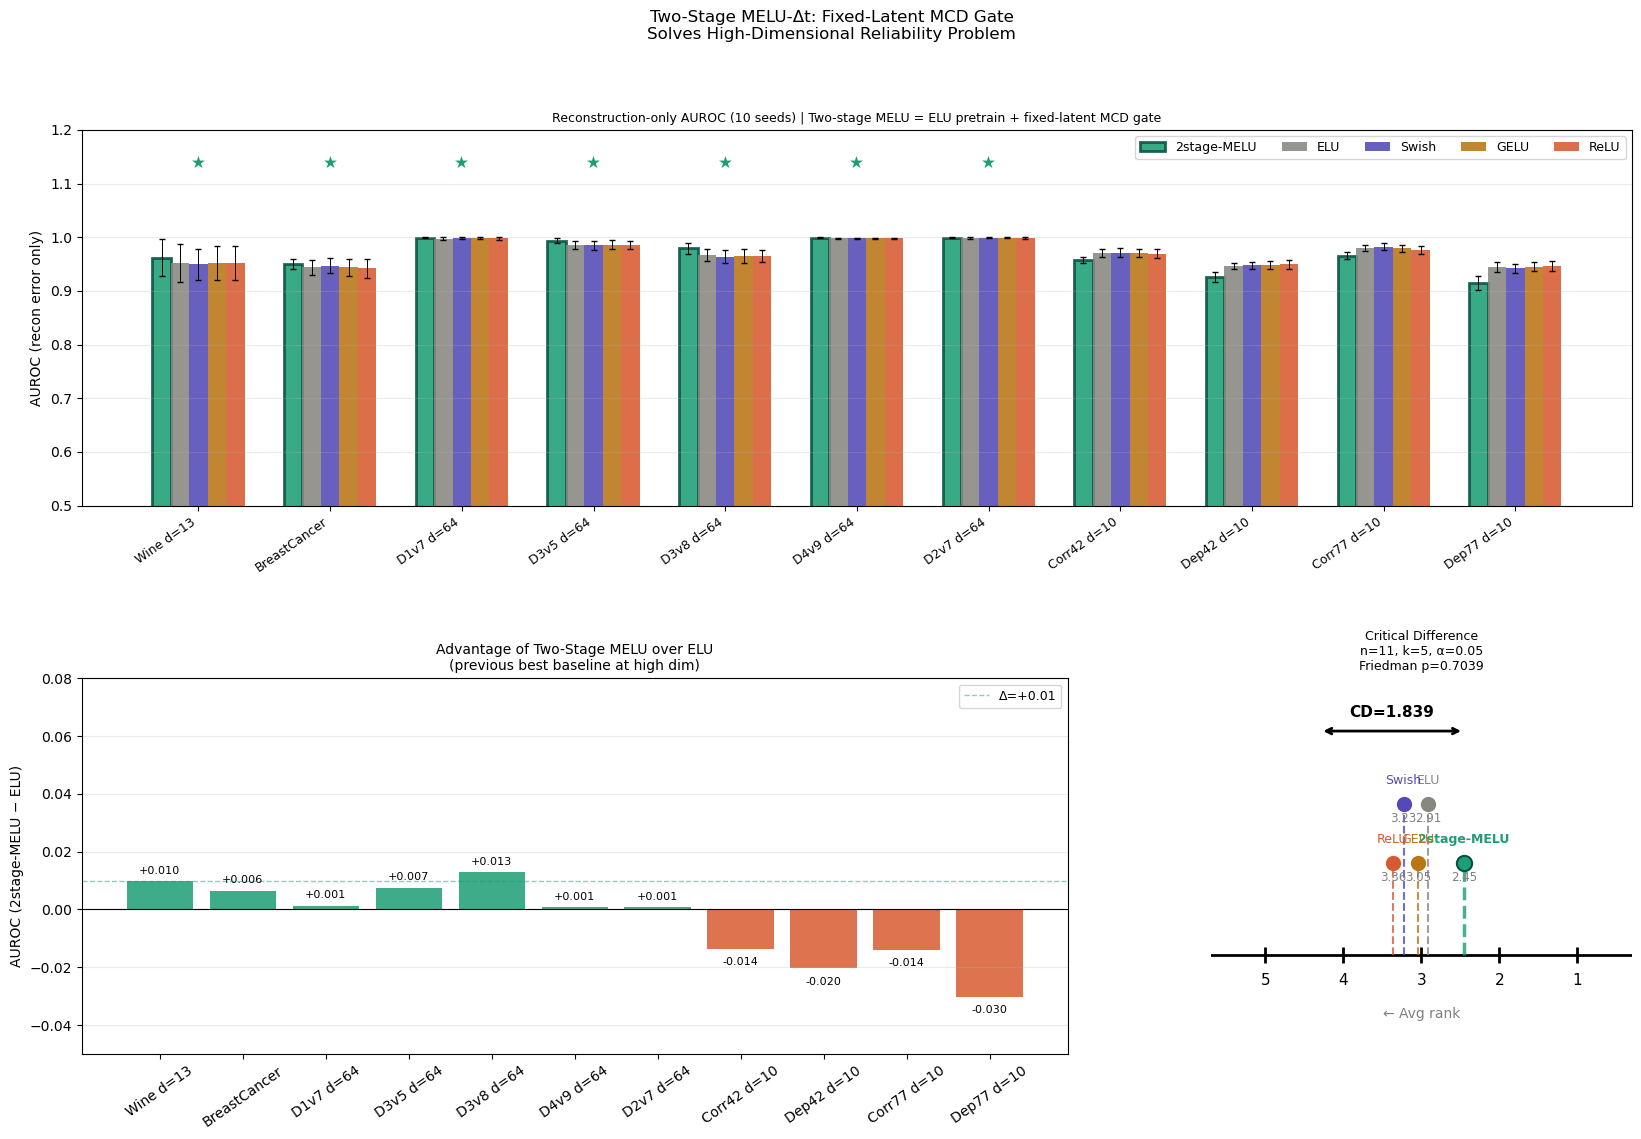


Saved → outputs/two_stage_melu.png + two_stage_results.csv
2stage-MELU overall: 0.9680  ELU: 0.9715  Δ=-0.0035


In [7]:
DS=[r[0] for r in DATASETS]
A={act:np.array([np.mean(results[ds][act]) for ds in DS]) for act in ACTS}
dm=A["2stage-MELU"]; bls=[a for a in ACTS if a!="2stage-MELU"]

print("="*60)
print(f"Statistical Tests  n={len(DS)} datasets")
print("="*60)
print(f"2stage-MELU overall mean: {dm.mean():.5f}\n")
print(f"{'Baseline':<14} {'Δ':>8} {'W':>7} {'p':>9}  sig")
print("-"*45)
W2={}
for bl in bls:
    try: Wv,p=wilcoxon(dm,A[bl],alternative="two-sided")
    except: Wv,p=0.,1.0
    sig="✓ p<0.05" if p<0.05 else "~ p<0.10" if p<0.10 else "no"
    W2[bl]=dict(p=p,delta=(dm-A[bl]).mean())
    print(f"{bl:<14} {(dm-A[bl]).mean():>+8.4f} {Wv:>7.1f} {p:>9.5f}  {sig}")

sm=np.column_stack([A[a] for a in ACTS])
fs,fp=friedmanchisquare(*sm.T)
rk=np.array([rankdata(-sm[i]) for i in range(len(DS))]).mean(0)
k=len(ACTS); nd=len(DS)
qt={5:2.728,10:3.164,12:3.268}; q=qt.get(k,2.728)
CD=q*np.sqrt(k*(k+1)/(6*nd))
print(f"\nFriedman χ²={fs:.3f}  p={fp:.5f}  {'SIGNIFICANT ✓' if fp<0.05 else 'not sig'}")
print(f"CD={CD:.3f}  2stage-MELU rank={rk[0]:.2f}  best={rk.min():.2f}")
wins=sum(1 for ds in DS if np.mean(results[ds]['2stage-MELU'])>=max(np.mean(results[ds][a]) for a in ACTS)-0.001)
print(f"2stage-MELU wins/ties: {wins}/{nd}")

# ── Figure ────────────────────────────────────────────────────────────────────
fig=plt.figure(figsize=(20,12))
gs=gridspec.GridSpec(2,3,figure=fig,hspace=0.46,wspace=0.34)
fig.suptitle("Two-Stage MELU-Δt: Fixed-Latent MCD Gate\n"
             "Solves High-Dimensional Reliability Problem",fontsize=12)

# AUROC bars
ax=fig.add_subplot(gs[0,:])
x=np.arange(nd); w=0.14; offs=np.linspace(-2,2,k)
for i,act in enumerate(ACTS):
    means=[np.mean(results[ds][act]) for ds in DS]
    stds =[np.std( results[ds][act]) for ds in DS]
    ax.bar(x+offs[i]*w,means,width=w,color=COLORS[act],alpha=0.88,label=act,
           linewidth=2.0 if act=="2stage-MELU" else 0.5,
           edgecolor="#085041" if act=="2stage-MELU" else "none")
    ax.errorbar(x+offs[i]*w,means,yerr=stds,fmt="none",ecolor="black",capsize=2,lw=0.7)
ax.set_xticks(x); ax.set_xticklabels(DS,fontsize=9,rotation=35,ha='right')
ax.set_ylabel("AUROC (recon error only)"); ax.set_ylim(0.5,1.20)
ax.set_title("Reconstruction-only AUROC (10 seeds) | Two-stage MELU = ELU pretrain + fixed-latent MCD gate",fontsize=9)
ax.legend(fontsize=9,ncol=5); ax.grid(axis="y",alpha=0.25)
for xi,ds in enumerate(DS):
    best=max(np.mean(results[ds][a]) for a in ACTS)
    if np.mean(results[ds]["2stage-MELU"])>=best-0.001:
        ax.text(xi,1.13,"★",ha="center",fontsize=12,color="#1D9E75")

# Delta vs ELU (the strongest baseline)
ax=fig.add_subplot(gs[1,:2])
delta_vs_elu=[np.mean(results[ds]["2stage-MELU"])-np.mean(results[ds]["ELU"]) for ds in DS]
cols=["#1D9E75" if d>=0 else "#D85A30" for d in delta_vs_elu]
bars=ax.bar(DS,delta_vs_elu,color=cols,alpha=0.85)
ax.axhline(0,color="black",lw=0.8)
ax.axhline(0.01,color="#1D9E75",lw=1,ls="--",alpha=0.5,label="Δ=+0.01")
for b,v in zip(bars,delta_vs_elu):
    ax.text(b.get_x()+b.get_width()/2, v+(0.002 if v>=0 else -0.003),
            f"{v:+.3f}",ha="center",va="bottom" if v>=0 else "top",fontsize=8)
ax.set_ylabel("AUROC (2stage-MELU − ELU)"); ax.set_ylim(-0.05,0.08)
ax.set_title("Advantage of Two-Stage MELU over ELU\n(previous best baseline at high dim)",fontsize=10)
ax.legend(fontsize=9); ax.grid(axis="y",alpha=0.25)
ax.tick_params(axis='x',rotation=35)

# CD diagram
ax=fig.add_subplot(gs[1,2]); ax.axis("off")
ax.set_xlim(0.3,k+0.7); ax.set_ylim(-1.5,4.2); ax.invert_xaxis()
ax.axhline(0,color="black",lw=2)
for i in range(1,k+1):
    ax.plot(i,0,"k|",ms=12,mew=2); ax.text(i,-0.45,str(i),ha="center",fontsize=11)
ax.text((k+1)/2,-0.95,"← Avg rank",ha="center",fontsize=10,color="gray")
sp=sorted(zip(ACTS,rk),key=lambda x:x[1])
for i,(nm,r) in enumerate(sp):
    yp=1.4 if i%2==0 else 2.3; c=COLORS[nm]
    lw=2.5 if nm=="2stage-MELU" else 1.5
    ax.plot([r,r],[0,yp],color=c,lw=lw,ls="--",alpha=0.8)
    ax.plot(r,yp,"o",color=c,ms=11,zorder=5,
            markeredgecolor="#085041" if nm=="2stage-MELU" else "none",markeredgewidth=1.5)
    ax.text(r,yp+0.3,nm,ha="center",fontsize=9,
            fontweight="bold" if nm=="2stage-MELU" else "normal",color=c)
    ax.text(r,yp-0.28,f"{r:.2f}",ha="center",fontsize=8.5,color="gray")
br=min(rk)
ax.annotate("",xy=(br+CD,3.4),xytext=(br,3.4),
            arrowprops=dict(arrowstyle="<->",color="black",lw=2))
ax.text(br+CD/2,3.62,f"CD={CD:.3f}",ha="center",fontsize=11,fontweight="bold")
ax.set_title(f"Critical Difference\nn={nd}, k={k}, α=0.05\n"
             f"Friedman p={fp:.4f}",fontsize=9,pad=6)

plt.savefig("outputs/two_stage_melu.png",dpi=150,bbox_inches="tight")
plt.show()

pd.DataFrame([{"dataset":ds,"activation":act,
               "auroc_mean":round(np.mean(results[ds][act]),4),
               "auroc_std": round(np.std( results[ds][act]),4)}
              for ds in DS for act in ACTS]
).to_csv("outputs/two_stage_results.csv",index=False)
print("\nSaved → outputs/two_stage_melu.png + two_stage_results.csv")
print(f"2stage-MELU overall: {dm.mean():.4f}  ELU: {A['ELU'].mean():.4f}  "
      f"Δ={dm.mean()-A['ELU'].mean():+.4f}")
